## Practical case 1
Sofía Jimeno Lucía

In [1]:
## Libraries
from matplotlib import pyplot as plt
import numpy as np
import cv2
import os
import re
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
## Variables
path_img = './dataset/'
list_dir = os.listdir(path_img)

### Getting redness ocuppancy

In [3]:
def redness_ocuppancy(im, plot = True):
    '''
        Getting the grade of redness from a bulbar conjuntiva image
        Input:
            - image, np.array, image to check
            - plot, boolean, for plotting the images
        Output:
            - list(float), grade of redness or blood vessels
    '''
    # Selecting channel and region of interest
    im_channel = im[270:550, 300:750, 1].copy()
    
    # Clahe transformation
    clahe = cv2.createCLAHE(clipLimit = 5.0, tileGridSize = (8,8))
    im_clahe = clahe.apply(im_channel)
    
    # Binarization
    _, img_bin = cv2.threshold(im_clahe, 100, 255, cv2.THRESH_BINARY)
    
    # Ocuppancy of blood vessels
    red_level = len(img_bin[img_bin == 0])/(img_bin.shape[0] * img_bin.shape[1])
    print(red_level)
    
    # Plotting images
    if plot:
        fu, ax = plt.subplots(1, 4, figsize = (18,18))
        ax[0].imshow(im[270:550,300:750,::-1])
        ax[1].imshow(im_channel, cmap = 'gray')

        ax[2].imshow(im_clahe, cmap = 'gray')  
        ax[3].imshow(img_bin, cmap = 'gray')
        plt.show()
        
    return [red_level]


0.11197619047619048


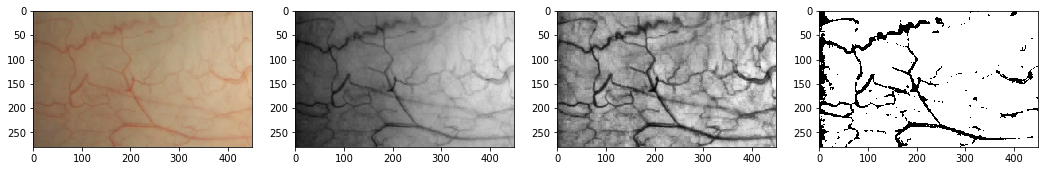

0.37424603174603177


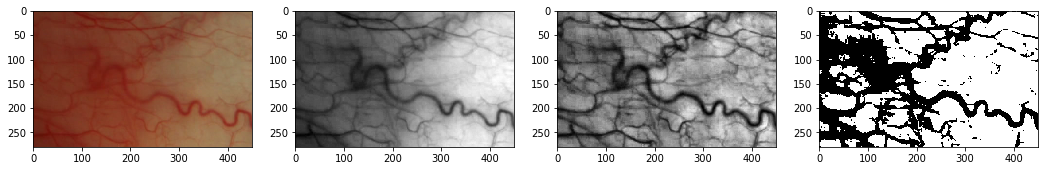

0.13286507936507935


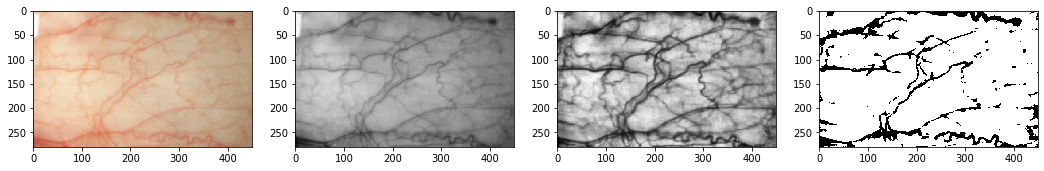

0.21153968253968253


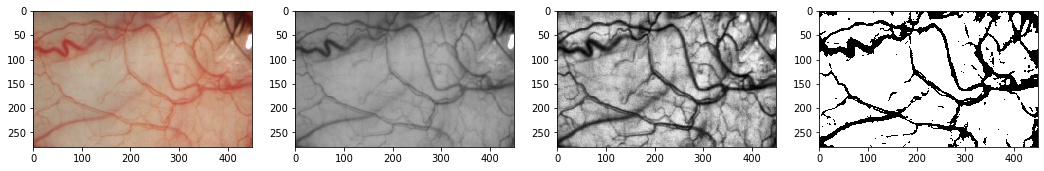

0.0746031746031746


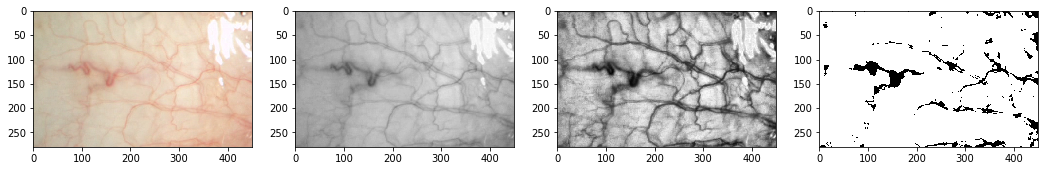

0.04730952380952381


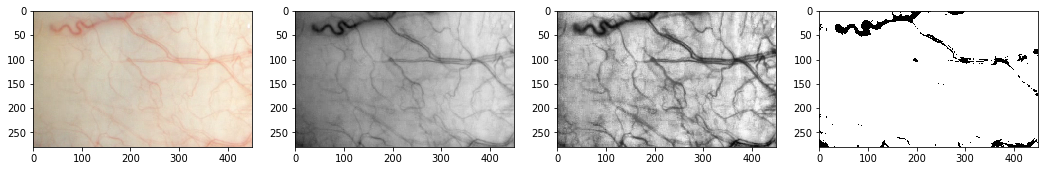

0.13354761904761905


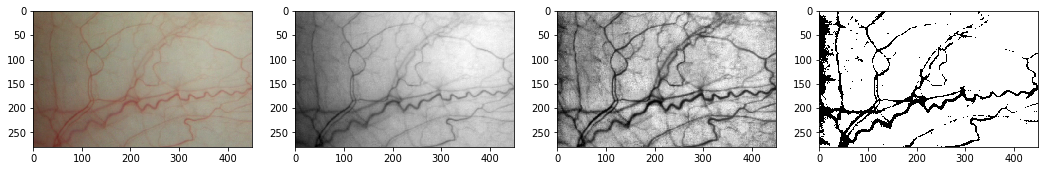

0.0571984126984127


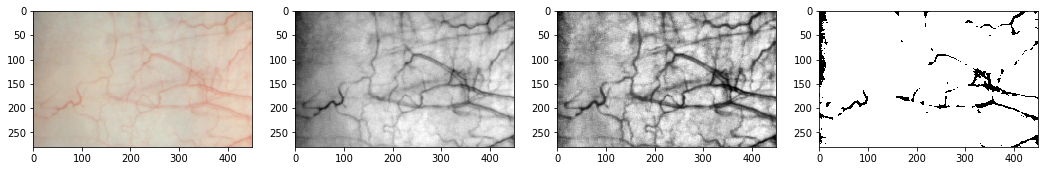

0.2793253968253968


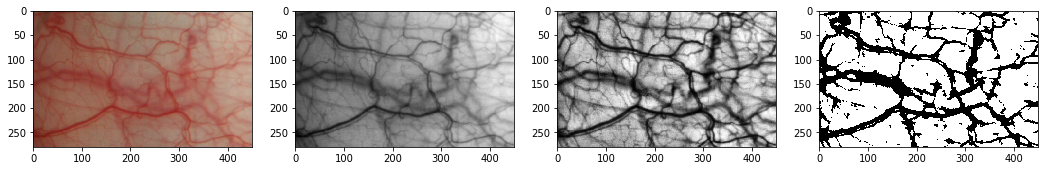

0.17273809523809525


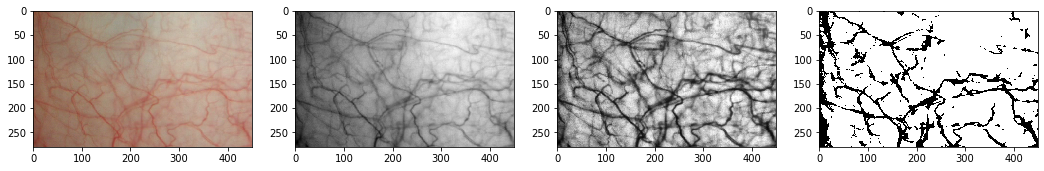

In [4]:
y_test = []
list_red_level = []

for img_file in list_dir:
    im = cv2.imread(path_img + img_file)
    list_red_level += redness_ocuppancy(im)
    
    m = re.search('(_\d.\d\.)|(_\d\.)', img_file)
    classification = float(m.group(0)[1:-1])

    if classification < 1.5:
        y_test += ['low']
    elif classification < 2.5:
        y_test += ['medium']
    else:
        y_test += ['high']
    


### Classification

In [5]:
y_pred = []
for level in list_red_level:
    if level <= 0.13:
        y_pred += ['low']
    elif level < 0.2:
        y_pred += ['medium']
    else:
        y_pred += ['high']

In [6]:
## Results
pd.DataFrame(list(zip(list_dir,y_test, y_pred)),columns=['file','specialist classfication','methodology classification'])

,file,specialist classfication,methodology classification
0,BN_024_1.1.jpg,low,low
1,BN_056_3.jpg,high,high
2,BN_058_2.jpg,medium,medium
3,BN_12_2.5.BMP,high,high
4,BN_15_1.BMP,low,low
5,BN_19_1.BMP,low,low
6,BT_03_1.BMP,low,medium
7,BT_04_1.BMP,low,low
8,BT_12_2.5.BMP,high,high
9,BT_13_2.BMP,medium,medium


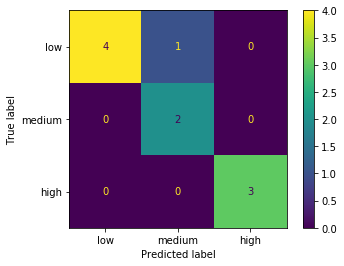

In [7]:
## Confusion matrix
cm = confusion_matrix(np.array(y_test), np.array(y_pred), labels = ['low','medium','high'])
disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels = ['low','medium','high'])
disp.plot()